In [22]:
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from statsmodels.tsa.api import ExponentialSmoothing
from datetime import date

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)


# CITYWIDE

In [23]:
cut_off = '2025-06-01'
last_cut_off = '2025-12-20'
last_day = '2025-12-31'

In [24]:
df = pd.read_csv('../scr/data/cleaned_rat_sightings_data/cleaned_rat_sightings.csv')
df['created_date'] = pd.to_datetime(df['created_date']) 
daily_counts = df.groupby(df['created_date'].dt.date).size().reset_index(name='count')
df = daily_counts
df['created_date'] = pd.to_datetime(df['created_date']) 

In [25]:
df_test = df[df['created_date']>=cut_off].copy()
df_train = df[df['created_date']<cut_off].copy()

holt_winters = ExponentialSmoothing(df_train['count'].values,
                                      seasonal='add',
                                      seasonal_periods=365).fit(optimized = True)

In [26]:
rs = pd.read_csv('../scr/data/cleaned_rat_sightings_data/cleaned_rat_sightings.csv')

In [27]:
rs['created_date'] = pd.to_datetime(rs['created_date']) 
rs['closed_date'] = pd.to_datetime(rs['closed_date'])
rs['resolution_action_updated_date'] = pd.to_datetime(rs['resolution_action_updated_date'])


# Start by cutting off datas before 2020-01-01 and after 2025-12-31.

rs = rs[rs['created_date']<=last_day]
rs = rs[rs['created_date']>='2020-01-01']


day_before_obj = datetime.datetime.strptime(cut_off, '%Y-%m-%d') - datetime.timedelta(days=1)
# Convert back to string (date only)
before_cut_off = day_before_obj.strftime('%Y-%m-%d')

rs_train = rs[rs['created_date']<cut_off]
rs_test = rs[rs['created_date']>=cut_off]

In [28]:
nrs_test = rs_test.groupby([rs_test['created_date'].dt.date]).size().reset_index(name='count')

nrs_train = rs_train.groupby([rs_train['created_date'].dt.date]).size().reset_index(name='count')

full_range = pd.date_range(start="2020-01-01", end=before_cut_off, freq='D')

# reindex and fill missing dates with 0
nrs_train = nrs_train.set_index('created_date').reindex(full_range, fill_value=0).rename_axis('created_date').reset_index()

full_range = pd.date_range(start=cut_off, end="2025-12-31",freq='D')

# reindex and fill missing dates with 0
nrs_test = nrs_test.set_index('created_date').reindex(full_range, fill_value=0).rename_axis('created_date').reset_index()

def seasonal_average_forecast(data, target_dates, years_back=5, day_window=5):
    df = data.copy()
    # ensure datetime type
    df["created_date"] = pd.to_datetime(df["created_date"])
    df["doy"] = df["created_date"].dt.dayofyear
    df["year"] = df["created_date"].dt.year

    forecasts = []
    for target_date in target_dates:
        target_doy = target_date.dayofyear
        target_year = target_date.year
        mask = ((df["year"] >= target_year - years_back) & (df["year"] < target_year) & (np.abs(df["doy"] - target_doy) <= day_window))
        forecasts.append(df.loc[mask, "count"].mean())
    return pd.Series(forecasts, index=target_dates)


# define future dates
# number of years to forecast
# years_to_forecast = 1

years_back = 5
day_window = 5

last_date = nrs_train["created_date"].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=len(nrs_test), freq="D")

forecast = seasonal_average_forecast(nrs_train, future_dates, years_back=years_back, day_window = day_window)


In [29]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(120, 50), sharex=False)

## Holt-Winters Plot

ax1.plot(df_train['created_date'], df_train['count'], 'o', color='b', label="Training Data", alpha=1, markersize=10)
ax1.plot(df_train['created_date'], holt_winters.fittedvalues, 'g-', label="Holt-Winters Fit", linewidth=8)
ax1.plot(df_test['created_date'], df_test['count'], 'o', color='b', label="Test Data", alpha=0.3, markersize=10)

hw_forecast = holt_winters.forecast(len(df_test['created_date']))
ax1.plot(df_test['created_date'], hw_forecast, color='black', label="Holt-Winters Predictions", linewidth=8)

ax1.grid(True)

ax1.set_xlabel("Date", fontsize=75)
ax1.set_ylabel("Rat Sightings by Day", fontsize=75)
ax1.tick_params(axis='x', labelsize=80)
ax1.tick_params(axis='y', labelsize=80)

ax1.set_title(f"Holt-Winters Prediction Trained on Data Before and Tested on Data After {cut_off}", fontsize=90)

# Metrics
rmse_hw = np.sqrt(np.mean((df_test['count'] - hw_forecast) ** 2))
rss_hw = np.sum((df_test['count'] - hw_forecast) ** 2)

text_box_hw = Patch(facecolor='white', edgecolor='black', label=f'RMSE: {rmse_hw:.2f}')
text_box2_hw = Patch(facecolor='white', edgecolor='black', label=f'RSS: {rss_hw:.2f}')

handles, labels = ax1.get_legend_handles_labels()
handles.extend([text_box_hw, text_box2_hw])
labels.extend([f"RMSE: {rmse_hw:.2f}", f"RSS: {rss_hw:.2f}"])
ax1.legend(handles=handles, labels=labels, fontsize=75)


## Seasonal Average Plot

ax2.plot(nrs_train["created_date"], nrs_train["count"], "o", color="b", markersize=10, label="Observed (Train)")
ax2.plot(forecast.index, forecast.values, color="black", linewidth=5, linestyle="-", label="Seasonal Avg Forecast")
ax2.plot(nrs_test["created_date"], nrs_test["count"], "o", color="b", markersize=10, alpha=0.3, label="Observed (Test)")

ax2.grid(True)
ax2.set_xlabel("Date", fontsize=75)
ax2.set_ylabel("Rat Sightings by Day", fontsize=75)
ax2.tick_params(axis='x', labelsize=80)
ax2.tick_params(axis='y', labelsize=80)

# Metrics
rmse_sa = np.sqrt(np.mean((nrs_test['count'] - forecast.values) ** 2))
rss_sa = np.sum((nrs_test['count'] - forecast.values) ** 2)

text_box_sa = Patch(facecolor='white', edgecolor='black', label=f'RMSE: {rmse_sa:.2f}')
text_box2_sa = Patch(facecolor='white', edgecolor='black', label=f'RSS: {rss_sa:.2f}')

handles, labels = ax2.get_legend_handles_labels()
handles.extend([text_box_sa, text_box2_sa])
labels.extend([f"RMSE: {rmse_sa:.2f}", f"RSS: {rss_sa:.2f}"])

ax2.legend(handles=handles, labels=labels, fontsize=75)
ax2.set_title(f"Daily Rat Sightings in NYC: Seasonal Average Forecast (Years Back = {years_back}, Day Window = {day_window})", fontsize=90)


plt.tight_layout()
plt.show()

In [30]:
## retuns the residual sum of squares
holt_winters.sse

530910.4786549241

In [31]:
## returns the Akaike information criterion.
holt_winters.aic

11795.979209407631

In [32]:
## returns Bayesian information criterion.
holt_winters.bic

13847.451044378666

In [33]:
## returns the residuals
holt_winters.resid

array([ -3.15331234,  19.62800965,   5.43637097, ...,   9.09732415,
         9.04770822, -16.46836199])

In [34]:
## returns the parameters
holt_winters.params

{'smoothing_level': 0.07589252606885039,
 'smoothing_trend': nan,
 'smoothing_seasonal': 0.0,
 'damping_trend': nan,
 'initial_level': 50.739903764521486,
 'initial_trend': nan,
 'initial_seasons': array([-30.58659142, -30.12860057, -16.42658113, -18.08955216,
         -8.05973392,  -2.90050003, -10.62561006, -20.79383602,
        -20.79517339, -19.42995437, -11.91789561, -10.06475403,
         -9.75696604,  -7.94273763, -15.62071198, -16.63979898,
        -29.08884141, -16.90900035, -16.37961244, -21.66226953,
        -26.37724892, -18.67904485, -24.18665993, -14.99338513,
         -9.45738005, -10.08842776,  -9.74526071,  -4.25789822,
         -8.98615628, -16.80593903, -20.27581077, -17.11781577,
        -14.42463697, -16.08799375, -15.77353186, -23.16332837,
        -17.77692453, -13.94107622, -15.72900287, -12.06639851,
        -10.20952488, -11.02894237, -19.77951533, -15.09868396,
        -22.75224736, -22.40981217, -15.70429331, -11.86546048,
        -16.89286107, -22.93660014,

In [35]:
## returns the parameters as a pandas dataframe
holt_winters.params_formatted

,name,param,optimized
smoothing_level,alpha,0.075893,True
smoothing_seasonal,gamma,0.000000,True
initial_level,l.0,50.739904,True
initial_seasons.0,s.0,-30.586591,True
initial_seasons.1,s.1,-30.128601,True
...,...,...,...
initial_seasons.360,s.360,-35.262640,True
initial_seasons.361,s.361,-26.867977,True
initial_seasons.362,s.362,-19.497669,True
initial_seasons.363,s.363,-18.739429,True


# TABLE OF COMPARISONS

In [36]:
cut_off = '2025-06-01'
last_cut_off = '2025-12-20'
last_day = '2025-12-31'

In [37]:
def seasonal_average_forecast(data, target_dates, years_back=5, day_window=5):
    df = data.copy()
    # ensure datetime type
    df["created_date"] = pd.to_datetime(df["created_date"])
    df["doy"] = df["created_date"].dt.dayofyear
    df["year"] = df["created_date"].dt.year

    forecasts = []
    for target_date in target_dates:
        target_doy = target_date.dayofyear
        target_year = target_date.year
        mask = ((df["year"] >= target_year - years_back) & (df["year"] < target_year) & (np.abs(df["doy"] - target_doy) <= day_window))
        forecasts.append(df.loc[mask, "count"].mean())
    return pd.Series(forecasts, index=target_dates)

In [38]:
date_list = pd.date_range(start="2025-01-01", end=last_cut_off).strftime("%Y-%m-%d").tolist()
metrics_table = pd.DataFrame(columns=['cut_off_date', 'rss_hw_train', 'rmse_hw', 'rss_hw', 'rmse_sa', 'rss_sa'])

In [39]:
init_df = pd.read_csv('../scr/data/cleaned_rat_sightings_data/cleaned_rat_sightings.csv')
init_df['created_date'] = pd.to_datetime(init_df['created_date'])
daily_counts = init_df.groupby(init_df['created_date'].dt.date).size().reset_index(name='count')
init_df = daily_counts
init_df['created_date'] = pd.to_datetime(init_df['created_date'])
init_df = init_df[init_df['created_date'] <= last_day]


init_rs = pd.read_csv('../scr/data/cleaned_rat_sightings_data/cleaned_rat_sightings.csv')
init_rs['created_date'] = pd.to_datetime(init_rs['created_date']) 
init_rs['closed_date'] = pd.to_datetime(init_rs['closed_date'])
init_rs['resolution_action_updated_date'] = pd.to_datetime(init_rs['resolution_action_updated_date'])



In [40]:
for cut_off in date_list:
    df = init_df.copy()
    df['created_date'] = pd.to_datetime(df['created_date']) 
    df_test = df[df['created_date']>=cut_off].copy()
    df_train = df[df['created_date']<cut_off].copy()

    holt_winters = ExponentialSmoothing(df_train['count'].values, seasonal='add',seasonal_periods=365).fit(optimized = True)

    if len(df_test['created_date'])==0:
        break
    hw_forecast = holt_winters.forecast(len(df_test['created_date']))

    rs = init_rs.copy()

    # Start by cutting off datas before 2020-01-01 and after 2025-12-31.
    rs['created_date'] = pd.to_datetime(rs['created_date']) 
    rs = rs[rs['created_date']<=last_day]
    rs = rs[rs['created_date']>='2020-01-01']


    day_before_obj = datetime.datetime.strptime(cut_off, '%Y-%m-%d') - datetime.timedelta(days=1)
    # Convert back to string (date only)
    before_cut_off = day_before_obj.strftime('%Y-%m-%d')

    rs_train = rs[rs['created_date']<cut_off]
    rs_test = rs[rs['created_date']>=cut_off]

    nrs_test = rs_test.groupby([rs_test['created_date'].dt.date]).size().reset_index(name='count')
    nrs_train = rs_train.groupby([rs_train['created_date'].dt.date]).size().reset_index(name='count')

    full_range = pd.date_range(start="2020-01-01", end=before_cut_off, freq='D')

    # reindex and fill missing dates with 0
    nrs_train = nrs_train.set_index('created_date').reindex(full_range, fill_value=0).rename_axis('created_date').reset_index()

    full_range = pd.date_range(start=cut_off, end="2025-12-31",freq='D')

    # reindex and fill missing dates with 0
    nrs_test = nrs_test.set_index('created_date').reindex(full_range, fill_value=0).rename_axis('created_date').reset_index()


    # define future dates
    # number of years to forecast
    # years_to_forecast = 1

    years_back = 5
    day_window = 5
    last_date = nrs_train["created_date"].max()
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=len(nrs_test), freq="D")
    forecast = seasonal_average_forecast(nrs_train, future_dates, years_back=years_back, day_window = day_window)

    # Metrics
    rmse_hw = np.sqrt(np.mean((df_test['count'] - hw_forecast) ** 2))
    rss_hw = np.sum((df_test['count'] - hw_forecast) ** 2)

    rmse_sa = np.sqrt(np.mean((nrs_test['count'] - forecast.values) ** 2))
    rss_sa = np.sum((nrs_test['count'] - forecast.values) ** 2)

    metrics_table = pd.concat([metrics_table, 
                               pd.DataFrame({'cut_off_date': [cut_off], 'rss_hw_train': [holt_winters.sse],
                                             'rmse_hw': [rmse_hw],
                                             'rss_hw': [rss_hw],
                                             'rmse_sa': [rmse_sa],
                                             'rss_sa': [rss_sa]})],
                              ignore_index=True)

/var/folders/ry/m6r2ndwd10bdv8tvww5hr2680000gn/T/ipykernel_43697/3870326113.py:59: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_table = pd.concat([metrics_table,


In [41]:
metrics_table

,cut_off_date,rss_hw_train,rmse_hw,rss_hw,rmse_sa,rss_sa
0,2025-01-01,488949.299083,20.542442,153605.055830,19.275769,135617.673860
1,2025-01-02,489178.463215,20.253661,148906.508292,19.271416,135185.033860
2,2025-01-03,489183.280002,20.242808,148337.200522,19.288335,135050.473860
3,2025-01-04,489211.938127,20.181559,147033.607368,19.313966,135036.598235
4,2025-01-05,490064.204082,19.839472,141697.680115,19.311197,134624.959223
...,...,...,...,...,...,...
349,2025-12-16,600013.692505,11.661467,2039.847022,20.099144,6463.609335
350,2025-12-17,600022.371663,11.970698,2006.166715,19.928121,5956.950162
351,2025-12-18,600461.651119,12.240143,1947.674294,20.161781,5690.963716
352,2025-12-19,600064.508956,12.707529,1937.775614,19.929945,5163.635121


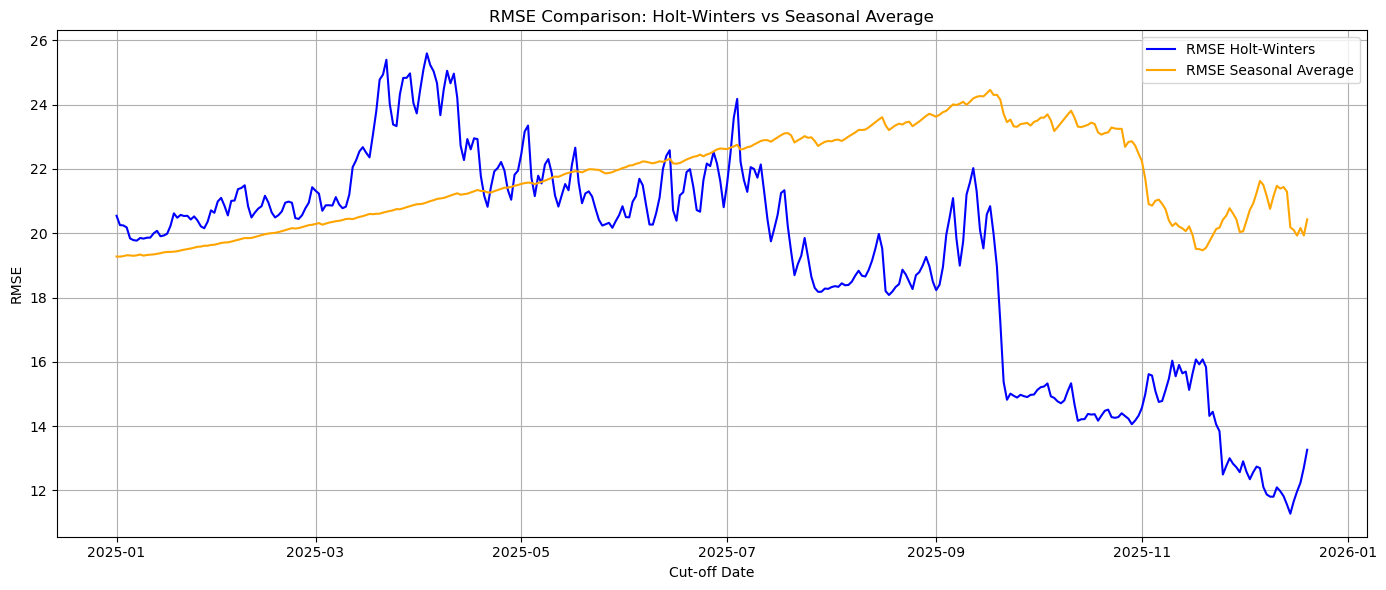

In [42]:

metrics_table['cut_off_date'] = pd.to_datetime(metrics_table['cut_off_date'])

plt.figure(figsize=(14,6))
plt.plot(metrics_table['cut_off_date'], metrics_table['rmse_hw'], label='RMSE Holt-Winters', color='blue')
plt.plot(metrics_table['cut_off_date'], metrics_table['rmse_sa'], label='RMSE Seasonal Average', color='orange')
plt.xlabel('Cut-off Date')
plt.ylabel('RMSE')
plt.title('RMSE Comparison: Holt-Winters vs Seasonal Average')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## CONCLUSIONS

It appears that the HOLT-WINTERS model gets better around roughly 2026-06-01 cut-off date and stays better for most of the remaining cut offs. 

Note that this is for CITYWIDE rat sightings. This should not be particularly surprising though. The seasonal average forecast is going to have roughly the same RMSE not matter the cut off date is. On the other hand, the HOLT-WINTERS forecast should get better the test set gets smaller since we get smaller forecast horizons.